# Imports
Imports required for this notebook

In [1]:
import pandas as pd
import sys
import seaborn as sns
import matplotlib.pyplot as plt
import math
sys.path.append('..')
from pipeline.preprocessors.missing import MissingValueHandler
from pipeline.preprocessors.revised_missing import RevisedMissingValueHandler


# Load Data
Load the **diabetes.csv** file.
Initialise the MissingValueHandler class with the parameters we want to drop, impute and values to zero.
## Configuration
Based on exploration findings:
- Drop Insulin: 48% of values were missing zeros, unreliable for imputation
- Mean impute Glucose and BloodPressure: Approximately normal distributions
- Median impute SkinThickness and BMI: Right skewed distributions
- Drop rows with 2 or more suspicious zeros: Records where more than half
  of clinical measurements are missing are unreliable for training

In [2]:
df = pd.read_csv('../../data/diabetes.csv')

In [3]:
impossibles = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']
handler = MissingValueHandler(
    drop_col =['Insulin'],
    mean_col = ['Glucose', 'BloodPressure'],
    median_col = ['SkinThickness', 'BMI'],
    zero_cols = impossibles
)

In [4]:
df_clean = handler.fit_transform(df)
df_clean.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148.0,72.0,35.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,43.1,2.288,33,1


## Shape check
Expecting 733 rows — 35 dropped due to 2 or more suspicious zeros.
Insulin column removed, leaving 8 columns.

In [5]:
df_clean.shape

(733, 8)

## Null check
Expecting zero nulls in all columns — imputation should have filled all NaN values.

In [6]:
df_clean.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

## Zero check
Expecting zero suspicious zeros remaining in cleaned columns.
Pregnancies and Outcome zeros are legitimate and should remain.

In [7]:
(df_clean == 0).sum()

Pregnancies                 101
Glucose                       0
BloodPressure                 0
SkinThickness                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     481
dtype: int64

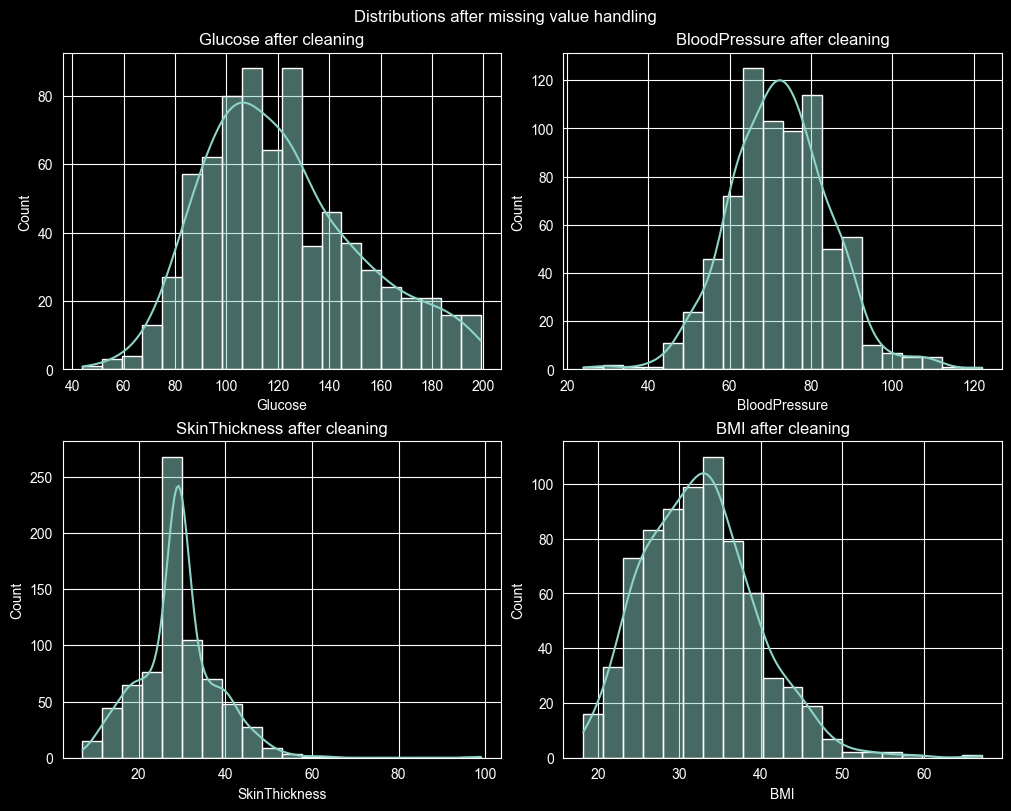

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8), constrained_layout=True)

cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'BMI']

for ax, col in zip(axes.flatten(), cols):
    sns.histplot(df_clean[col], bins=20, kde=True, ax=ax)
    ax.set_title(f'{col} after cleaning')

plt.suptitle('Distributions after missing value handling')
plt.show()

In [9]:
df_clean['SkinThickness'].value_counts().head(10)

SkinThickness
29.0    209
32.0     31
30.0     27
27.0     23
23.0     22
33.0     20
18.0     20
28.0     20
31.0     19
19.0     18
Name: count, dtype: int64

# Results
Handler working correctly. Data is clean and ML-ready for numerical scaling.
## Issue: SkinThickness artificial peaking
227 missing values (29.5%) all imputed with the same median value, creating an artificial spike in the distribution. This misrepresents the true spread of the data and could affect model performance. KNN imputation would be a more appropriate strategy for columns with high missingness.

## Imputation Strategy, Automated Selection
- Missing > 20% → KNN imputation (SkinThickness: 29.5%)
- Missing < 20%, skewed (skew > 0.5) → median imputation
- Missing < 20%, normal (skew < 0.5) → mean imputation

In [10]:
# Common rule for number of K nearest-neighbours:
math.sqrt(733)

27.073972741361768

## KNN-Review
- The common rule is too many neighbours as it will average too broadly.
- Either hardcode between 5-10 or allow the user to pass in K-value.

# Revised Handler
Revised handler to handle skewed columns, SkinThickness overloading issue and better conditional fitting.

In [11]:
revised_handler = RevisedMissingValueHandler(
    drop_cols=['Insulin'],
    impute_cols=['Glucose', 'BloodPressure', 'SkinThickness', 'BMI'],
    zero_cols=impossibles,
    knn_neighbors=3
)

df_clean_revised = revised_handler.fit_transform(df)

In [12]:
df_clean_revised.shape

(733, 8)

In [13]:
df_clean_revised.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [14]:
(df_clean_revised == 0).sum()

Pregnancies                 101
Glucose                       0
BloodPressure                 0
SkinThickness                 0
BMI                           0
DiabetesPedigreeFunction      0
Age                           0
Outcome                     481
dtype: int64

# Results
The same cleaning results in terms of removing 0's and Null values from the dataset.
## Fixed SkinThickness Issue

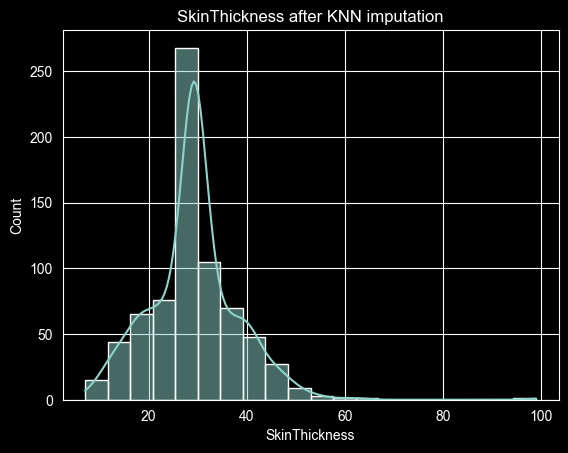

In [15]:
sns.histplot(df_clean_revised['SkinThickness'], bins=20, kde=True)
plt.title('SkinThickness after KNN imputation')
plt.show()

In [16]:
comparison = pd.DataFrame({
    'Before cleaning': df['SkinThickness'].value_counts().head(20),
    'Median imputation': df_clean['SkinThickness'].value_counts().head(20),
    'KNN imputation': df_clean_revised['SkinThickness'].value_counts().head(20)
}).fillna(0).astype(int)

comparison

,Before cleaning,Median imputation,KNN imputation
SkinThickness,,,
0.00000,227,0,0
15.00000,0,14,0
18.00000,20,20,20
19.00000,18,18,18
22.00000,16,16,16
23.00000,22,22,22
25.00000,16,16,16
26.00000,16,16,16
27.00000,23,23,23


# SkinThickness Results
KNN calculates values close to the median score, regardless of K-Value. With k=27,5 and 3 KNN imputation converges to a single value (29.15) for all 192 missing SkinThickness values, behaving similarly to median imputation. Lower k values may produce more varied imputations but risk overfitting to individual patients. High missingness (29.5%) limits imputation quality regardless of strategy.